In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from skimage.feature import local_binary_pattern, hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from collections import Counter

In [ ]:
!pip install kaggle

In [ ]:
import json

kaggle_dict = {
    "username": "suchitrasiddharthan",
    "key": "KGAT_53b502f93f9f912e8cf30ed32d60157d"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import os
import shutil

base_dir = "dataset_clean"

classes = ["COVID", "Normal", "Pneumonia"]

for cls in classes:
    os.makedirs(os.path.join(base_dir, cls), exist_ok=True)

In [ ]:
import random

MAX_IMAGES = 1000

def copy_images(src, dst, max_images):
    files = os.listdir(src)
    random.shuffle(files)

    count = 0
    for f in files:
        if count >= max_images:
            break
        try:
            shutil.copy(os.path.join(src, f), dst)
            count += 1
        except:
            continue

In [ ]:
# COVID images
copy_images("COVID-19_Radiography_Dataset/COVID/images",
            "dataset_clean/COVID", MAX_IMAGES)

# Normal (ONLY from COVID dataset)
copy_images("COVID-19_Radiography_Dataset/Normal/images",
            "dataset_clean/Normal", MAX_IMAGES)

# Pneumonia (ONLY from pneumonia dataset)
copy_images("chest_xray/train/PNEUMONIA",
            "dataset_clean/Pneumonia", MAX_IMAGES)

In [ ]:
def extract_features(image):

    # Resize SAME as backend
    image = cv2.resize(image, (224,224))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255.0

    features = []

    # ---------- GLCM ----------
    img_uint8 = (gray * 255).astype(np.uint8)
    levels = 16
    step = 256 // levels
    img_q = (img_uint8 // step).astype(np.uint8)

    glcm = graycomatrix(
        img_q,
        distances=[1,2,3],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=levels,
        symmetric=True,
        normed=True
    )

    props = ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']
    for p in props:
        vals = graycoprops(glcm, p)
        features.append(vals.mean())
        features.append(vals.std())

    # ---------- LBP (IMPORTANT FIX) ----------
    lbp = local_binary_pattern(img_uint8, P=16, R=2, method='uniform')
    hist,_ = np.histogram(lbp.ravel(),
                          bins=np.arange(0, 18+1),
                          range=(0,18))
    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-8)

    features.extend(hist)

    # ---------- HOG (IMPORTANT FIX) ----------
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    features.extend(hog_features)

    return np.array(features)

In [ ]:
X = []
y = []

MAX_IMAGES = 1000  # limit per class

# Define the dataset_clean dictionary
dataset_clean = {
    "COVID": os.path.join(base_dir, "COVID"),
    "Normal": os.path.join(base_dir, "Normal"),
    "Pneumonia": os.path.join(base_dir, "Pneumonia")
}

for label, folder in dataset_clean.items():
    count = 0

    for img_name in tqdm(os.listdir(folder), desc=label):

        if count >= MAX_IMAGES:
            break

        path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(path)

            if img is None:
                continue

            features = extract_features(img)

            X.append(features)
            y.append(label)

            count += 1

        except:
            continue

X = np.array(X)
y = np.array(y)

Pneumonia: 100%|██████████| 1000/1000 [01:10<00:00, 14.23it/s]


In [ ]:
print("Class Distribution:", Counter(y))

Class Distribution: Counter({np.str_('COVID'): 1000, np.str_('Normal'): 1000, np.str_('Pneumonia'): 1000})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
def evaluate_model(model, name):

    y_pred = model.predict(X_test)

    print(f"\n🔹 {name} Results")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
results = {}

def evaluate_model(model, name):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n🔹 {name} Classification Report")
    print("-"*50)
    print(classification_report(y_test, y_pred))

    results[name] = {
        "accuracy": acc,
        "f1_score": f1,
        "y_pred": y_pred
    }

# Run for all models
evaluate_model(svm_model, "SVM")
evaluate_model(rf_model, "Random Forest")
evaluate_model(knn_model, "KNN")


🔹 SVM Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       COVID       0.90      0.92      0.91       200
      Normal       0.92      0.90      0.91       200
   Pneumonia       1.00      1.00      1.00       200

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600


🔹 Random Forest Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       COVID       0.83      0.84      0.83       200
      Normal       0.86      0.82      0.84       200
   Pneumonia       0.95      0.98      0.97       200

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600


🔹 KNN Classification Report
---------------------------------------

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

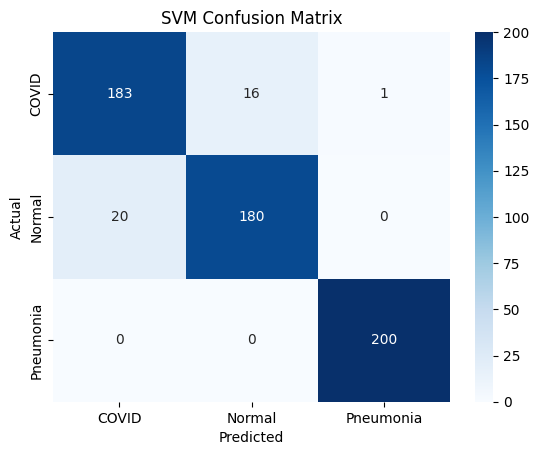

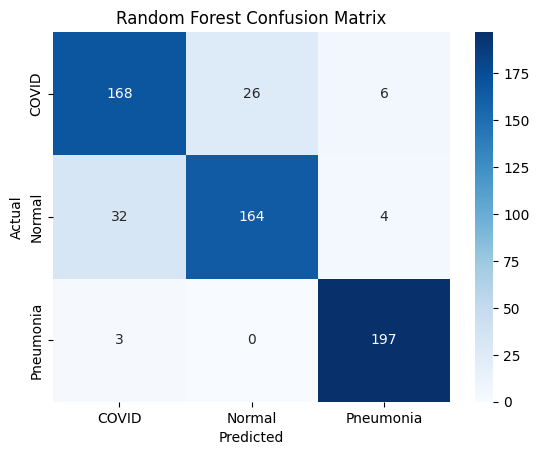

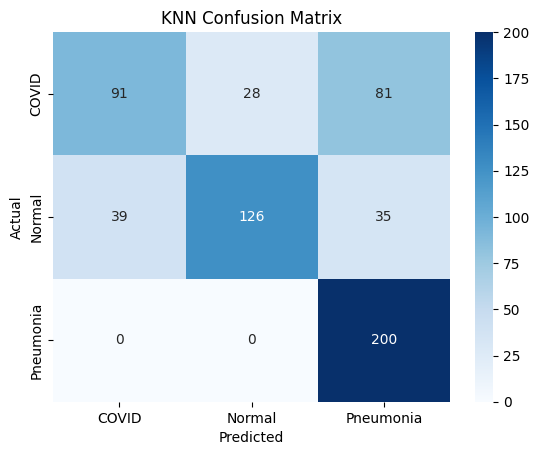

In [ ]:
for name in results:
    plot_confusion_matrix(y_test, results[name]["y_pred"], f"{name} Confusion Matrix")

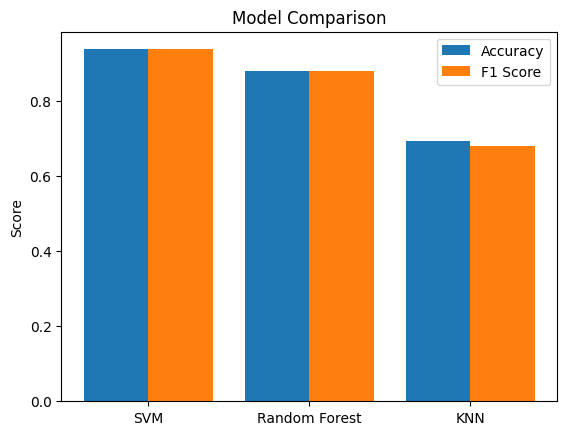

In [ ]:
models = list(results.keys())
accuracy = [results[m]["accuracy"] for m in models]
f1_scores = [results[m]["f1_score"] for m in models]

x = np.arange(len(models))

plt.figure()

plt.bar(x - 0.2, accuracy, width=0.4, label="Accuracy")
plt.bar(x + 0.2, f1_scores, width=0.4, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.show()

In [ ]:
model_path = "/content/drive/MyDrive/lung_models"

In [ ]:
import os
os.makedirs(model_path, exist_ok=True)

In [ ]:
import pickle

pickle.dump(svm_model, open(f"{model_path}/svm_model.pkl", "wb"))
pickle.dump(rf_model, open(f"{model_path}/rf_model.pkl", "wb"))
pickle.dump(knn_model, open(f"{model_path}/knn_model.pkl", "wb"))
pickle.dump(scaler, open(f"{model_path}/scaler.pkl", "wb"))

In [ ]:
from google.colab import files

files.download(f"{model_path}/svm_model.pkl")
files.download(f"{model_path}/rf_model.pkl")
files.download(f"{model_path}/knn_model.pkl")
files.download(f"{model_path}/scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>